In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, cohen_kappa_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
BASE_PATH = os.getcwd()
TEST_PATH = os.path.join(BASE_PATH, "Dataset", "test", "Shoulder")
MODEL_PATH = os.path.join(BASE_PATH, "weights", "EfficientNetB1_Shoulder.h5")

In [3]:
model= tf.keras.models.load_model(MODEL_PATH)

In [4]:
dataset = []

for patient in os.listdir(TEST_PATH):
    patient_path = os.path.join(TEST_PATH, patient)

    for study in os.listdir(patient_path):

        label = "fractured" if study.endswith("positive") else "normal"
        study_path = os.path.join(patient_path, study)

        for img in os.listdir(study_path):
            dataset.append({
                "Filepath": os.path.join(study_path, img),
                "Label": label
            })

df = pd.DataFrame(dataset)

In [5]:
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

test_images = datagen.flow_from_dataframe(
    dataframe=df,
    x_col="Filepath",
    y_col="Label",
    target_size=(224, 224),
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)


Found 557 validated image filenames belonging to 2 classes.


In [7]:
loss, accuracy = model.evaluate(test_images)
print("\nShoulderTest Accuracy:", accuracy)

y_pred_probs = model.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_images.classes

class_names = list(test_images.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

C:\Users\lenovo\AppData\Roaming\Python\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.8576 - loss: 0.4789

ShoulderTest Accuracy: 0.8473967909812927
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step

Classification Report:

              precision    recall  f1-score   support

   fractured       0.85      0.84      0.84       272
      normal       0.85      0.86      0.85       285

    accuracy                           0.85       557
   macro avg       0.85      0.85      0.85       557
weighted avg       0.85      0.85      0.85       557



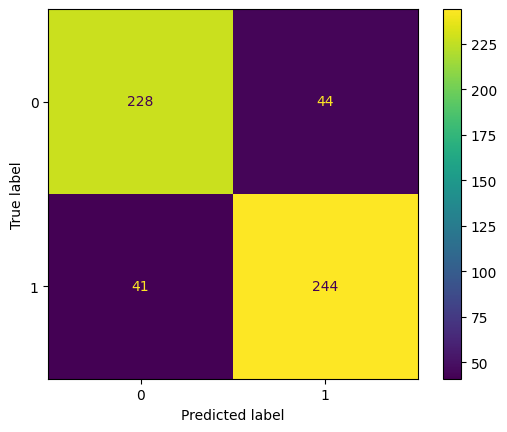

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

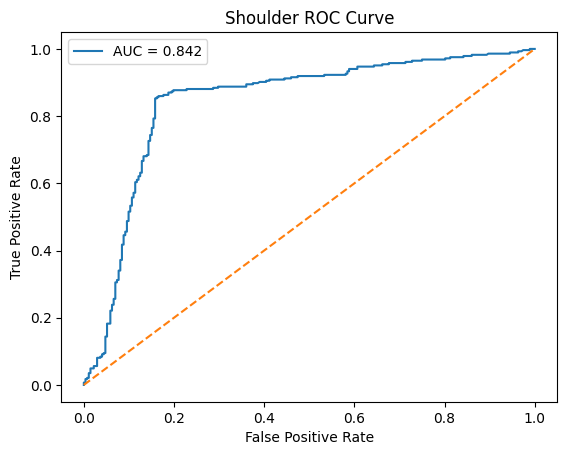

In [9]:
from sklearn.metrics import roc_curve, auc
# probabilities from model
probs = y_pred_probs
y_scores = probs[:,1]
# final ROC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Shoulder ROC Curve")
plt.legend()
plt.show()



In [10]:
kappa = cohen_kappa_score(y_true, y_pred)
print("\nCohen Kappa Score:", kappa)



Cohen Kappa Score: 0.6945503577396275
